# MPPIGreedy + gradient descent on the best rollout

This notebook drives the **`MPPIGreedy`** controller
(`analytic_mppi/controllers/mppi_greedy.py`) — argmin selection of the single best
rollout, cached as the nominal, with a configurable `keep`-step warm-start — and
applies the **same finite-difference cost gradient descent as `analysis-pt2.ipynb`**
to that best rollout each step, through the new `MPPIGreedy.act(..., refine_fn=...)`
hook.

Per control step, the **greedy+gd** controller:
1. samples `K` Gaussian perturbations of the nominal,
2. rolls them out and scores them (`total_cost` aggregation),
3. picks the single best (`argmin`),
4. **gradient-descends that best rollout** (`cost_descent`: central finite
   differences, projected to the control bounds — identical to Part 2b),
5. executes its first action and warm-starts (keep the first `keep` steps, zero the tail).

We compare three controllers that share the **same per-step noise** (same `seed`):
`mppi` (softmax average over all `K`, no GD), `greedy` (argmin best, no GD), and
`greedy+gd` (argmin best + GD) on **pendulum, hopper, and walker**, reporting the
*realized* closed-loop running cost (cost actually accrued on the executed trajectory).

In [49]:
import time
import numpy as np
import matplotlib.pyplot as plt

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPI, MPPIGreedy

print("controllers:", MPPI.__name__, "/", MPPIGreedy.__name__)

controllers: MPPI / MPPIGreedy


## Gradient-descent methodology (identical to `analysis-pt2.ipynb`)

`total_cost` (rollout cost), `cost_grad` (central finite differences in one batched
`+/-` rollout pair), and `cost_descent` (projected GD) are copied verbatim from
Part 2b. `make_cost_fn` adapts the same aggregation to `MPPIGreedy`'s
`cost_fn(states, controls, sensordata)` callback so the argmin scoring reuses the
controller's own rollout. `realized_terms` (Part 3) measures the running cost
actually accrued on the executed closed-loop trajectory.

In [50]:
def total_cost(controls, state, task, backend):
    """J per rollout (lower = better).  controls: (B, H, nu) -> (B,).

    Same aggregation as SamplingController._score_normal: sum of running-cost
    terms over (H, n_terms) plus the terminal-cost terms."""
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2))
    terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
    return running + terminal


def cost_grad(controls, state, task, backend, eps=1e-4):
    """Central-difference dJ/du through the rollout.  (K, H, nu) -> same shape.

    All H*nu coordinate perturbations are stacked into the batch dimension, so
    the whole gradient costs exactly TWO backend.rollout calls (the +/- sides)."""
    K, H, nu = controls.shape
    P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps     # (P, H, nu) one-hots
    base = controls[:, None]                                          # (K, 1, H, nu)
    plus  = (base + bump).reshape(K * P, H, nu)
    minus = (base - bump).reshape(K * P, H, nu)
    Jp = total_cost(plus,  state, task, backend).reshape(K, P)
    Jm = total_cost(minus, state, task, backend).reshape(K, P)
    return ((Jp - Jm) / (2.0 * eps)).reshape(K, H, nu)


def cost_descent(u, state, task, backend, n_iter, lr, eps=1e-4):
    """Projected GD on J (clip to bounds each step).  Mirrors smooth_descent.

    Returns (u_final, J_hist, gnorm_hist):
      J_hist     (n_iter + 1, K)  cost per rollout, row 0 = initial
      gnorm_hist (n_iter,     K)  ||dJ/du|| per rollout at each step (pre-step)"""
    u = np.clip(u.copy().astype(np.float64), task.u_min, task.u_max)
    K = u.shape[0]
    J_hist = np.empty((n_iter + 1, K)); J_hist[0] = total_cost(u, state, task, backend)
    g_hist = np.empty((n_iter, K))
    for t in range(n_iter):
        g = cost_grad(u, state, task, backend, eps)
        g_hist[t] = np.linalg.norm(g.reshape(K, -1), axis=1)
        u -= lr * g
        np.clip(u, task.u_min, task.u_max, out=u)
        J_hist[t + 1] = total_cost(u, state, task, backend)
    return u, J_hist, g_hist


def make_cost_fn(task):
    """MPPIGreedy cost_fn callback (states, controls, sensordata) -> (K,).

    Mirrors total_cost's aggregation but reuses the controller's own rollout
    (states/sensordata are already computed inside MPPIGreedy.act)."""
    def cost_fn(states, controls, sensordata):
        qpos, qvel = task.qpos_of(states), task.qvel_of(states)
        running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2))
        terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
        return running + terminal
    return cost_fn


def realized_terms(states_hist, ctrl_hist, task, backend):
    """Per-step running cost on the EXECUTED trajectory.  -> (T, n_terms).
    sensordata is recomputed via a one-step rollout so the locomotion sensors
    (height/vel/zaxis) are present and the cost matches the planner's convention."""
    post, sens = backend.rollout(states_hist[:-1], ctrl_hist[:, None, :])   # (T,1,*)
    qpos, qvel = task.qpos_of(post[:, 0]), task.qvel_of(post[:, 0])
    return task.running_cost_terms(qpos, qvel, sens[:, 0], ctrl_hist)

## Closed-loop sweep — pendulum, hopper, walker

Each controller runs receding-horizon from the same start state, with shared
per-step noise (all controllers seeded identically). Only **greedy+gd** passes
`cost_descent` into `MPPIGreedy.act` via `refine_fn`. `GREEDY_KEEP` exposes the
`keep` warm-start knob (`-1` -> the full `H-1`-step warm-start; lower values keep
fewer warm-started steps and re-explore more).

In [ ]:
SEED, GREEDY_KEEP = 0, -1                   # GREEDY_KEEP = -1 -> H-1 (full warm-start)
SIM_TIME = 50.0                            # closed-loop sim seconds per controller (T = round(SIM_TIME / dt))
METHODS = ("mppi", "greedy", "greedy+gd")
COLORS  = {"mppi": "tab:blue", "greedy": "tab:orange", "greedy+gd": "tab:green"}
# Per-env: optimal num_samples / noise (sigma) / temperature (lam) / horizon from the tuned knot-spline
# configs (num_knots/spline_type are knot-spline-only and don't apply to these full-control-space
# controllers). pendulum keeps its prior config (no tuned optimum given). GD knobs are notebook tuning.
ENV_CFG = {   # closed-loop steps T derived from SIM_TIME
    "pendulum": dict(plan_horizon=1.0, num_samples=32,  gd_iters=4, gd_lr=0.20, sigma=0.5, lam=1.0),
    "hopper":   dict(plan_horizon=0.6, num_samples=120, gd_iters=5, gd_lr=0.05, sigma=0.3, lam=0.05),
    "walker":   dict(plan_horizon=0.6, num_samples=128, gd_iters=5, gd_lr=0.25, sigma=0.5, lam=0.1),
}


def build_controller(method, task, H, cfg):
    """Real controller class instances; same seed -> same per-step noise across methods."""
    common = dict(horizon=H, n_samples=cfg["num_samples"], nu=task.nu,
                  sigma=np.full(task.nu, cfg["sigma"]), lambda_=cfg["lam"],
                  u_min=task.u_min, u_max=task.u_max, seed=SEED)
    if method == "mppi":
        return MPPI(**common)
    return MPPIGreedy(keep=GREEDY_KEEP, **common)


def run_closed_loop(method, task, backend, state0, H, cfg):
    """Receding-horizon rollout driven by the real controller class.
    greedy+gd refines the best rollout each step via MPPIGreedy.act(refine_fn=...).
    Returns (states (T+1, nstate), controls (T, nu), plan_time_s)."""
    ctrl = build_controller(method, task, H, cfg)
    cost_fn = make_cost_fn(task)
    refine_fn = None
    if method == "greedy+gd":
        refine_fn = lambda U, s: cost_descent(U, s, task, backend, cfg["gd_iters"], cfg["gd_lr"])[0]

    backend.set_state(state0); ctrl.reset()
    states_hist, ctrl_hist, t_plan = [backend.get_state().copy()], [], 0.0
    for t in range(cfg["T"]):
        state = backend.get_state()
        t0 = time.perf_counter()
        if refine_fn is not None:
            u0 = ctrl.act(state, cost_fn, backend, refine_fn=refine_fn)
        else:
            u0 = ctrl.act(state, cost_fn, backend)
        t_plan += time.perf_counter() - t0
        backend.step(u0)
        states_hist.append(backend.get_state().copy()); ctrl_hist.append(u0.copy())
    return np.array(states_hist), np.array(ctrl_hist), t_plan


for env_name, cfg in ENV_CFG.items():
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    cfg["T"] = round(SIM_TIME / backend.dt)   # closed-loop steps for SIM_TIME seconds of sim
    H, nu = round(cfg["plan_horizon"] / backend.dt), task.nu
    state0 = backend.get_state().copy()
    t_axis = backend.dt * np.arange(cfg["T"] + 1)

    runs = {}
    print(f"\n[{env_name}] H={H} nu={nu} T={cfg['T']} ({SIM_TIME:g}s) K={cfg['num_samples']} "
          f"GD={cfg['gd_iters']}x lr={cfg['gd_lr']} lam={cfg['lam']} keep={GREEDY_KEEP}  "
          f"(shared per-step noise)")
    print(f"{'method':>10s} | {'plan time':>9s} | {'realized J':>11s} | {'avg J/step':>10s}")
    for m in METHODS:
        sh, ch, tp = run_closed_loop(m, task, backend, state0, H, cfg)
        terms = realized_terms(sh, ch, task, backend)
        runs[m] = dict(stage=terms.sum(axis=1), per_term=terms.sum(axis=0))
        print(f"{m:>10s} | {tp:8.2f}s | {terms.sum():11.3f} | {terms.sum()/terms.shape[0]:10.4f}")

    # --- per-env figure: cumulative realized cost (left) + per-term realized cost (right) ---
    labels = list(task.cost_term_names) + ["total"]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
    for m in METHODS:
        axL.plot(t_axis[1:], np.cumsum(runs[m]["stage"]), color=COLORS[m], lw=1.6, label=m)
    axL.set_xlabel("time (s)"); axL.set_ylabel(r"$\sum \ell$ (realized)")
    axL.set_title("cumulative realized running cost"); axL.legend(loc="best"); axL.grid(alpha=0.3)

    x = np.arange(len(labels)); w = 0.27
    for i, m in enumerate(METHODS):
        vals = np.append(runs[m]["per_term"], runs[m]["per_term"].sum())
        axR.bar(x + (i - 1) * w, vals, w, color=COLORS[m], alpha=0.85, label=m)
    axR.set_yscale("log"); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
    axR.set_ylabel("realized cost (sum over T, log)"); axR.set_title("per-term realized cost")
    axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3, which="both")

    fig.suptitle(f"{env_name}: closed-loop MPPI vs greedy vs greedy+GD  "
                 f"(H={H}, K={cfg['num_samples']}, T={cfg['T']}, {SIM_TIME:g}s)", y=1.04)
    fig.tight_layout(); plt.show()

## Latent-space MPPI — matched-dimension basis selection (reconstruction vs rollout)

Same **base MPPI** as `mppi.py` (sample → rollout → softmax weights → warm-start),
but perturbations are drawn in a **`D`-dimensional latent** rather than the full
`(H, nu)` control space. Two bases are kept at the **same budget `D = k·nu`** and
compared head-to-head each refit:

- **`CosineBasis(H, nu, k)`** — fixed DCT, `k` low-frequency modes per actuator
  (dim `k·nu = D`); the generic smooth prior.
- **`PCABasis(B, H, nu, D)`** — whitened PCA fit jointly over the controller's own
  flattened nominal plans, kept at **exactly `D`** components; distills
  cross-actuator coordination from the buffer (demo-free).

**Selection gate (reversible — switch to PCA if it wins, else keep cosine; no
margin, no freeze).** Each refit fits a candidate PCA at dimension `D` and picks
the better basis by one of two metrics — giving the two latent methods:

1. **`recon`** — lower **reconstruction error** on held-out recent plans.
2. **`rollout`** — lower **min MPPI cost** when sampling `K` fresh plans in that
   basis from the *current* state.

On a switch the nominal is decoded to a control trajectory and re-encoded in the
new basis (so the controller doesn't lurch); samples combine in **control space**
(`U_new = Σ wᵢ Uᵢ`); whitening keeps a single sigma meaningful as the PCA fit
changes; an `explore_frac` reserve keeps sampling in the cosine basis.

This cell defines the bases + `LatentMPPI` + the reusable `compare_methods` sweep
and runs **base MPPI vs the reconstruction gate**. The next cell adds the
**rollout-cost gate** and the full **3-way** comparison, closed-loop 50 s on
walker / hopper / g1_standup (g1 uses a smaller `K`).

In [51]:
# ============================================================================
# Latent-space MPPI - matched-dimension basis selection (cosine(D) vs PCA(D))
# ============================================================================
# Same base MPPI loop as mppi.py (sample -> rollout -> softmax weights ->
# warm-start), but perturbations are drawn in a D-dimensional latent. Two bases
# are kept at the SAME budget D = k * nu: a fixed cosine (DCT) basis with k modes
# per actuator, and a PCA basis (exactly D components) fit from the controller's
# own nominal-plan buffer. Each refit picks the basis that is genuinely better at
# dimension D - switch to PCA if it wins, else keep cosine (reversible; no margin,
# no freeze). Two selection metrics give two methods:
#   "recon"   -> lower reconstruction error on held-out recent plans
#   "rollout" -> lower min MPPI cost when sampling in that basis from the current
#                state (defined/used in the next cell).
# Reuses np/plt/time/MPPI (cell 1) and make_cost_fn/realized_terms (cell 3).
from collections import deque


class CosineBasis:
    """Fixed orthonormal DCT-II basis over the horizon, k modes per actuator.

    Latent dim = k * nu = D. Not whitened (coeffs in control units, so sigma_cos
    is comparable to base MPPI's sigma).
    """

    def __init__(self, H, nu, k):
        d = int(min(k, H))
        n = np.arange(H)[:, None]
        j = np.arange(d)[None, :]
        Phi = np.cos(np.pi * (2 * n + 1) * j / (2 * H))
        a = np.full(d, np.sqrt(2.0 / H)); a[0] = np.sqrt(1.0 / H)
        self.Phi = Phi * a                               # (H, k) orthonormal cols
        self.H, self.nu, self.k = H, nu, d

    @property
    def D(self):
        return self.k * self.nu

    @property
    def latent_shape(self):
        return (self.k, self.nu)

    def encode(self, U):                                 # (..., H, nu) -> (..., k, nu)
        return np.einsum("hk,...hj->...kj", self.Phi, U)

    def decode(self, z):                                 # (..., k, nu) -> (..., H, nu)
        return np.einsum("hk,...kj->...hj", self.Phi, z)

    def recon_err(self, U):
        return float(np.mean((U - self.decode(self.encode(U))) ** 2))


class PCABasis:
    """Whitened PCA basis fit jointly over flattened (H*nu) plans, kept at rank D.

    Exactly d = min(D, rank) components (NO variance trimming) so it is compared
    against the cosine basis at the same latent dimension D. Joint over H*nu so the
    latent captures cross-actuator coordination; whitened by singular values so a
    single sigma stays meaningful as the fit changes.
    """

    def __init__(self, B, H, nu, D, eps=1e-8):
        self.mean = B.mean(axis=0)
        Bc = B - self.mean
        _, S, Vt = np.linalg.svd(Bc, full_matrices=False)
        d = int(min(D, Vt.shape[0]))
        self.V = Vt[:d]                                  # (d, H*nu)
        N = max(Bc.shape[0] - 1, 1)
        self.s = (S[:d] / np.sqrt(N)) + eps              # per-axis data std (whitening)
        self.H, self.nu, self.d = H, nu, d

    @property
    def D(self):
        return self.d

    @property
    def latent_shape(self):
        return (self.d,)

    def encode(self, U):                                 # (..., H, nu) -> (..., d)
        flat = U.reshape(U.shape[:-2] + (self.H * self.nu,))
        return ((flat - self.mean) @ self.V.T) / self.s

    def decode(self, z):                                 # (..., d) -> (..., H, nu)
        flat = self.mean + (z * self.s) @ self.V
        return flat.reshape(z.shape[:-1] + (self.H, self.nu))

    def recon_err(self, U):
        return float(np.mean((U - self.decode(self.encode(U))) ** 2))


class LatentMPPI:
    """MPPI sampling in a latent basis; each refit selects cosine(D) vs PCA(D).

    gate_mode = "reconstruction" -> pick the basis with lower held-out recon error.
    gate_mode = "rollout"        -> pick the basis with lower min rollout cost
                                    (fresh samples from the current state).
    gate_mode = None             -> fixed-cosine latent MPPI (no refit).
    Selection is reversible (can revert to cosine); no margin, no freeze.
    `act(state, cost_fn, backend)` matches MPPI.act.
    """

    def __init__(self, *, horizon, n_samples, nu, lambda_, u_min=None, u_max=None,
                 seed=0, k=4, sigma_cos=0.5, sigma_pca=1.0, gate_mode="reconstruction",
                 buffer_size=600, refit_every=200, warmup=200, explore_frac=0.2,
                 verbose=False):
        self.H, self.K, self.nu = horizon, n_samples, nu
        self.lambda_ = lambda_
        self.u_min = None if u_min is None else np.asarray(u_min, float).reshape(nu)
        self.u_max = None if u_max is None else np.asarray(u_max, float).reshape(nu)
        self.seed = seed
        self.k = k
        self.D = k * nu
        self.sigma_cos, self.sigma_pca = sigma_cos, sigma_pca
        self.gate_mode = gate_mode
        self.buffer_size = buffer_size
        self.refit_every, self.warmup = refit_every, warmup
        self.explore_frac = explore_frac if gate_mode is not None else 0.0
        self.verbose = verbose
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(self.seed)
        self.cosine = CosineBasis(self.H, self.nu, self.k)
        self.active = self.cosine
        self.basis_name = "cosine"
        self.mu_z = np.zeros(self.active.latent_shape)
        self.buffer = deque(maxlen=self.buffer_size)
        self.step = 0
        self.switch_log = []          # (step, choose, metric_cos, metric_pca)

    def _clip(self, U):
        if self.u_min is not None or self.u_max is not None:
            return np.clip(U, self.u_min, self.u_max)
        return U

    def _sample(self, basis, center_z, sigma, K):
        z = center_z[None] + sigma * self.rng.normal(size=(K,) + center_z.shape)
        return basis.decode(z)                           # (K, H, nu)

    def _sigma_for(self, basis):
        return self.sigma_cos if basis is self.cosine else self.sigma_pca

    def _rollout_cost(self, U, state, cost_fn, backend):
        U = self._clip(U)
        initial = np.broadcast_to(state, (U.shape[0], state.shape[0])).copy()
        states, sensordata = backend.rollout(initial, U)
        return np.asarray(cost_fn(states, U, sensordata), float).reshape(U.shape[0])

    def act(self, state, cost_fn, backend):
        K_res = int(round(self.K * self.explore_frac))
        K_main = self.K - K_res

        U_main = self._sample(self.active, self.mu_z, self._sigma_for(self.active), K_main)
        if K_res > 0:
            c0 = self.cosine.encode(self.active.decode(self.mu_z))    # current nominal in cosine coords
            U = np.concatenate([U_main, self._sample(self.cosine, c0, self.sigma_cos, K_res)], axis=0)
        else:
            U = U_main
        U = self._clip(U)

        costs = self._rollout_cost(U, state, cost_fn, backend)
        beta = costs.min()
        w = np.exp(-(costs - beta) / self.lambda_)
        s = w.sum()
        if s <= 0 or not np.isfinite(s):
            U_new = U[int(np.argmin(costs))].copy()
        else:
            U_new = (w[:, None, None] / s * U).sum(axis=0)            # combine in CONTROL space

        self.mu_z = self.active.encode(U_new)
        self.buffer.append(U_new.reshape(-1).copy())
        self.step += 1

        if self.gate_mode is not None:
            self._maybe_select(state, cost_fn, backend)

        # warm-start shift in control space
        U_nom = self.active.decode(self.mu_z)
        u0 = self._clip(U_nom[0].copy())                             # decode isn't bound-preserving
        U_shift = np.roll(U_nom, -1, axis=0); U_shift[-1] = 0.0
        self.mu_z = self.active.encode(U_shift)
        return u0

    def _maybe_select(self, state, cost_fn, backend):
        if self.step % self.refit_every != 0 or len(self.buffer) < self.warmup:
            return
        B = np.asarray(self.buffer)
        n_recent = max(1, B.shape[0] // 4)
        older, recent = B[:-n_recent], B[-n_recent:]
        if older.shape[0] <= self.D or recent.shape[0] < 1:
            return
        cand = PCABasis(older, self.H, self.nu, self.D)              # matched-D PCA fit

        if self.gate_mode == "reconstruction":
            recent_U = recent.reshape(-1, self.H, self.nu)
            m_cos = self.cosine.recon_err(recent_U)
            m_pca = cand.recon_err(recent_U)
        elif self.gate_mode == "rollout":
            nominal_U = self.active.decode(self.mu_z)
            U_cos = self._sample(self.cosine, self.cosine.encode(nominal_U), self.sigma_cos, self.K)
            U_pca = self._sample(cand, cand.encode(nominal_U), self.sigma_pca, self.K)
            m_cos = float(self._rollout_cost(U_cos, state, cost_fn, backend).min())
            m_pca = float(self._rollout_cost(U_pca, state, cost_fn, backend).min())
        else:
            return

        choose = "pca" if m_pca < m_cos else "cosine"
        target = cand if choose == "pca" else self.cosine
        if target is not self.active:                               # re-encode nominal on any basis change
            self.mu_z = target.encode(self.active.decode(self.mu_z))
            self.active = target
        self.basis_name = choose
        self.switch_log.append((self.step, choose, m_cos, m_pca))
        if self.verbose:
            print(f"    [select @ {self.step}] {self.gate_mode}: cos={m_cos:.4e} pca={m_pca:.4e} "
                  f"-> {choose}(d={self.active.D})")


# ---------------------------------------------------------------------------
# Closed-loop driver + per-env config + a reusable comparison sweep.
# Methods: "mppi" (base, control-space), "recon" (matched-D reconstruction gate),
# "rollout" (matched-D rollout-cost gate). g1 uses a smaller K (nu=29).
# ---------------------------------------------------------------------------
SIM_TIME = 50.0
SEED     = 0
COLORS   = {"mppi": "tab:blue", "recon": "tab:purple", "rollout": "tab:red"}

LAT_CFG = {   # per-env: horizon (s), cosine modes/actuator k (D=k*nu); num_knots+spline_type are used by
              # the knot method only; sigmas, K (num_samples), temp. Tuned-optimal K/noise/temp/horizon/knots.
    "walker":     dict(plan_horizon=0.6, k=4, num_knots=5,  spline_type="zero",  sigma_cos=0.5, sigma_pca=1.0, K=128, lam=0.1),
    "hopper":     dict(plan_horizon=0.6, k=4, num_knots=15, spline_type="cubic", sigma_cos=0.3, sigma_pca=1.0, K=120, lam=0.05),
    "g1_standup": dict(plan_horizon=0.6, k=3, num_knots=4,  spline_type="zero",  sigma_cos=0.3, sigma_pca=1.0, K=128, lam=0.1),
}
ADAPT_KW = dict(buffer_size=600, refit_every=200, warmup=200, explore_frac=0.2)


def build_latent(method, task, H, cfg):
    """base MPPI / matched-D reconstruction-gate latent / matched-D rollout-gate latent."""
    if method == "mppi":
        return MPPI(horizon=H, n_samples=cfg["K"], nu=task.nu,
                    sigma=np.full(task.nu, cfg["sigma_cos"]), lambda_=cfg["lam"],
                    u_min=task.u_min, u_max=task.u_max, seed=SEED)
    gate = "reconstruction" if method == "recon" else "rollout"
    return LatentMPPI(horizon=H, n_samples=cfg["K"], nu=task.nu, lambda_=cfg["lam"],
                      u_min=task.u_min, u_max=task.u_max, seed=SEED,
                      k=cfg["k"], sigma_cos=cfg["sigma_cos"], sigma_pca=cfg["sigma_pca"],
                      gate_mode=gate, verbose=True, **ADAPT_KW)


def run_cl(ctrl, task, backend, state0, T, cost_fn):
    """Receding-horizon rollout; same shape as cell 5's run_closed_loop."""
    backend.set_state(state0); ctrl.reset()
    states_hist, ctrl_hist, t_plan = [backend.get_state().copy()], [], 0.0
    for _ in range(T):
        state = backend.get_state()
        t0 = time.perf_counter()
        u0 = ctrl.act(state, cost_fn, backend)
        t_plan += time.perf_counter() - t0
        backend.step(u0)
        states_hist.append(backend.get_state().copy()); ctrl_hist.append(u0.copy())
    return np.array(states_hist), np.array(ctrl_hist), t_plan


def compare_methods(methods, tag):
    """Run `methods` closed-loop for SIM_TIME on each env; plot + print per env."""
    for env_name, cfg in LAT_CFG.items():
        task = make_task(env_name); backend = MujocoBackend(task.model_path)
        T = round(SIM_TIME / backend.dt)
        H = round(cfg["plan_horizon"] / backend.dt)
        state0 = backend.get_state().copy()
        t_axis = backend.dt * np.arange(T + 1)
        cost_fn = make_cost_fn(task)

        runs = {}
        print(f"\n[{env_name}] H={H} nu={task.nu} T={T} ({SIM_TIME:g}s)  "
              f"k={cfg['k']} D={cfg['k'] * task.nu} K={cfg['K']}  ({tag})")
        print(f"{'method':>8s} | {'plan time':>9s} | {'realized J':>11s} | {'avg J/step':>10s}")
        for m in methods:
            ctrl = build_latent(m, task, H, cfg)
            sh, ch, tp = run_cl(ctrl, task, backend, state0, T, cost_fn)
            terms = realized_terms(sh, ch, task, backend)
            runs[m] = dict(stage=terms.sum(axis=1), per_term=terms.sum(axis=0))
            extra = ""
            if isinstance(ctrl, LatentMPPI):
                sl = ctrl.switch_log
                npca = sum(1 for s in sl if s[1] == "pca")
                extra = f"  final={ctrl.basis_name} pca_chosen={npca}/{len(sl)}"
            print(f"{m:>8s} | {tp:8.2f}s | {terms.sum():11.3f} | {terms.sum()/terms.shape[0]:10.4f}{extra}")

        labels = list(task.cost_term_names) + ["total"]
        fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
        for m in methods:
            axL.plot(t_axis[1:], np.cumsum(runs[m]["stage"]), color=COLORS[m], lw=1.6, label=m)
        axL.set_xlabel("time (s)"); axL.set_ylabel(r"$\sum \ell$ (realized)")
        axL.set_title("cumulative realized running cost"); axL.legend(loc="best"); axL.grid(alpha=0.3)

        x = np.arange(len(labels)); w = 0.8 / max(len(methods), 1)
        for i, m in enumerate(methods):
            vals = np.append(runs[m]["per_term"], runs[m]["per_term"].sum())
            axR.bar(x + (i - (len(methods) - 1) / 2) * w, vals, w, color=COLORS[m], alpha=0.85, label=m)
        axR.set_yscale("log"); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
        axR.set_ylabel("realized cost (sum over T, log)"); axR.set_title("per-term realized cost")
        axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3, which="both")

        fig.suptitle(f"{env_name}: {tag}  (H={H}, K={cfg['K']}, D={cfg['k'] * task.nu}, "
                     f"T={T}, {SIM_TIME:g}s)", y=1.04)
        fig.tight_layout(); plt.show()


# Cell 7 stands alone: base MPPI vs the matched-D reconstruction gate.
#compare_methods(("mppi", "recon"), tag="matched-D reconstruction gate")

## Three-way comparison — `mppi` vs `recon` vs `rollout`

Adds the **rollout-cost gate** alongside the reconstruction gate and runs all
three methods together. Both latent methods keep cosine and PCA at the same
matched dimension `D = k·nu`; they differ only in how each refit chooses between
them — **reconstruction error on held-out plans** (`recon`) vs **min MPPI cost of
fresh samples drawn in each basis from the current state** (`rollout`). The
printed line reports each latent method's final active basis and how often PCA was
chosen (`pca_chosen / decisions`).

In [32]:
# ============================================================================
# 3-way comparison: base MPPI vs reconstruction-gate vs rollout-cost-gate latent
# ============================================================================
# Reuses CosineBasis / PCABasis / LatentMPPI / build_latent / compare_methods and
# LAT_CFG from the previous cell. The only difference between "recon" and
# "rollout" is the selection metric at each refit (held-out reconstruction error
# vs min rollout cost from the current state); both keep the two bases at the same
# matched dimension D = k * nu.
compare_methods(("mppi", "recon", "rollout"), tag="reconstruction vs rollout gate")


[walker] H=60 nu=6 T=1000 (10s)  k=4 D=24 K=128  (reconstruction vs rollout gate)
  method | plan time |  realized J
    mppi |    24.37s |     242.938


TypeError: LatentMPPI.__init__() got an unexpected keyword argument 'k'

## Knot-spline MPPI vs the rollout-cost gate

Head-to-head between two **low-dimensional control parameterizations** at a
matched parameter budget:

- **`knots`** — the knot-spline `MPPIv2` (`controllers/mppi_v2.py`): perturb
  `num_knots` control knots over the horizon and `cubic`-interpolate them onto the
  step grid. With `num_knots = k`, the knot budget `num_knots·nu` equals the
  latent dimension `D = k·nu` of the gate method — a *fixed smooth* basis.
- **`rollout`** — the rollout-cost-gate `LatentMPPI` from the cells above:
  cosine(D) vs PCA(D), reselected each refit by the **min MPPI cost of fresh
  samples drawn in each basis from the current state** — an *adaptively-selected*
  basis at the same dimension.

So this isolates fixed smooth knots against an adaptively-chosen latent basis at
equal dimension. Both are graded by the same **realized** running cost
(`realized_terms`), independent of how each scores internally — note `knots`
scores with `MPPIv2._score_normal` (running·dt + terminal) while `rollout` uses
`make_cost_fn` (running + terminal, no dt), so each pursues its own native
objective. `knots` warm-starts in knot space; `rollout` warm-starts in control
space. Runs closed-loop 50 s on walker / hopper / g1_standup (`LAT_CFG`).

In [52]:
# ============================================================================
# Knot-spline MPPI (MPPIv2) vs the matched-D rollout-cost gate (LatentMPPI)
# ============================================================================
# Two low-dim control parameterizations at a matched budget:
#   "knots"   -> MPPIv2: perturb num_knots = k control knots, cubic-interp to the
#                step grid (knot budget num_knots*nu == latent D = k*nu).
#   "rollout" -> the rollout-cost-gate LatentMPPI from the cells above.
# The two act() signatures differ (MPPIv2.act(state) scores internally via the
# task; LatentMPPI.act(state, cost_fn, backend)), so run_cl_any branches on type.
# Reuses LAT_CFG / ADAPT_KW / SEED / SIM_TIME / build_latent / LatentMPPI (latent
# cells) and make_cost_fn / realized_terms (cell 3).
from analytic_mppi.controllers import MPPIv2

KNOT_METHODS = ("knots", "rollout")
KNOT_COLORS  = {"knots": "tab:green", "rollout": "tab:red"}


def build_knots(task, backend, cfg):
    """Knot-spline MPPI at the env's tuned-optimal num_knots / spline_type; num_samples,
    noise_level and temperature reuse the same K / cosine-sigma / temperature as the gate
    methods so the two are run under matched sampling budgets."""
    return MPPIv2(task=task, backend=backend,
                  num_samples=cfg["K"], noise_level=cfg["sigma_cos"], temperature=cfg["lam"],
                  num_knots=cfg["num_knots"], plan_horizon=cfg["plan_horizon"],
                  spline_type=cfg["spline_type"], seed=SEED)


def run_cl_any(ctrl, backend, state0, T, cost_fn):
    """Receding-horizon driver supporting both act signatures (cf. run_cl)."""
    backend.set_state(state0); ctrl.reset()
    knot_api = isinstance(ctrl, MPPIv2)            # SamplingController.act(state)
    states_hist, ctrl_hist, t_plan = [backend.get_state().copy()], [], 0.0
    for _ in range(T):
        state = backend.get_state()
        t0 = time.perf_counter()
        u0 = ctrl.act(state) if knot_api else ctrl.act(state, cost_fn, backend)
        t_plan += time.perf_counter() - t0
        backend.step(u0)
        states_hist.append(backend.get_state().copy()); ctrl_hist.append(u0.copy())
    return np.array(states_hist), np.array(ctrl_hist), t_plan


for env_name, cfg in LAT_CFG.items():
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    T = round(SIM_TIME / backend.dt)
    H = round(cfg["plan_horizon"] / backend.dt)
    state0 = backend.get_state().copy()
    t_axis = backend.dt * np.arange(T + 1)
    cost_fn = make_cost_fn(task)

    ctrls = {"knots":   build_knots(task, backend, cfg),
             "rollout": build_latent("rollout", task, H, cfg)}

    runs = {}
    print(f"\n[{env_name}] H={H} nu={task.nu} T={T} ({SIM_TIME:g}s)  "
          f"num_knots={cfg['num_knots']} ({cfg['spline_type']}) latent_D={cfg['k'] * task.nu} K={cfg['K']}  "
          f"(knots vs rollout gate)")
    print(f"{'method':>8s} | {'plan time':>9s} | {'realized J':>11s} | {'avg J/step':>10s}")
    for m in KNOT_METHODS:
        ctrl = ctrls[m]
        sh, ch, tp = run_cl_any(ctrl, backend, state0, T, cost_fn)
        terms = realized_terms(sh, ch, task, backend)
        runs[m] = dict(stage=terms.sum(axis=1), per_term=terms.sum(axis=0))
        extra = ""
        if isinstance(ctrl, LatentMPPI):
            sl = ctrl.switch_log
            npca = sum(1 for s in sl if s[1] == "pca")
            extra = f"  final={ctrl.basis_name} pca_chosen={npca}/{len(sl)}"
        print(f"{m:>8s} | {tp:8.2f}s | {terms.sum():11.3f} | {terms.sum()/terms.shape[0]:10.4f}{extra}")

    labels = list(task.cost_term_names) + ["total"]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
    for m in KNOT_METHODS:
        axL.plot(t_axis[1:], np.cumsum(runs[m]["stage"]), color=KNOT_COLORS[m], lw=1.6, label=m)
    axL.set_xlabel("time (s)"); axL.set_ylabel(r"$\sum \ell$ (realized)")
    axL.set_title("cumulative realized running cost"); axL.legend(loc="best"); axL.grid(alpha=0.3)

    x = np.arange(len(labels)); w = 0.8 / len(KNOT_METHODS)
    for i, m in enumerate(KNOT_METHODS):
        vals = np.append(runs[m]["per_term"], runs[m]["per_term"].sum())
        axR.bar(x + (i - (len(KNOT_METHODS) - 1) / 2) * w, vals, w,
                color=KNOT_COLORS[m], alpha=0.85, label=m)
    axR.set_yscale("log"); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
    axR.set_ylabel("realized cost (sum over T, log)"); axR.set_title("per-term realized cost")
    axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3, which="both")

    fig.suptitle(f"{env_name}: knot-spline MPPI vs rollout-cost gate  "
                 f"(H={H}, K={cfg['K']}, num_knots={cfg['num_knots']}, T={T}, {SIM_TIME:g}s)", y=1.04)
    fig.tight_layout(); plt.show()


[walker] H=60 nu=6 T=5000 (50s)  num_knots=5 (zero) latent_D=24 K=128  (knots vs rollout gate)
  method | plan time |  realized J | avg J/step


KeyboardInterrupt: 

## Knot-spline MPPI vs the rollout-cost gate (switched on the last-T-state average)

Same head-to-head as the cell above, but the gate's selection rule is **temporally
averaged**. The earlier `rollout` gate decides cosine(D) vs PCA(D) from a single fresh
probe at the *current* state, which is noisy. Here the gate keeps a ring buffer of the
**last `T` visited states** (`AVG_WINDOW`) and, at each refit, draws `K` fresh samples in
each basis and rolls them out from `AVG_STATES` states subsampled across that window,
picking the basis with the lower **average** min-cost — so the switch depends on the
average cost over the last `T` timesteps rather than an instantaneous reading.

- **`splines`** — knot-spline `MPPIv2` at each env's tuned-optimal `num_knots` / `spline_type`.
- **`rollout_avg`** — `LatentMPPIAvgGate`, the averaged rollout-cost gate (a subclass of
  `LatentMPPI`; latent dim `D = k·nu`, with `k` kept at its tuned 4/4/3).

Selection stays reversible (no margin, no freeze); on a switch the nominal is re-encoded
in the new basis. Both methods are graded by the same realized running cost
(`realized_terms`). Runs closed-loop 50 s on walker / hopper / g1_standup (`LAT_CFG`).

In [54]:
# ============================================================================
# MPPI with splines vs the rollout-cost gate switched on the last-T-state average
# ============================================================================
# Same matched-D cosine(D) vs PCA(D) machinery as the "rollout" gate, but the
# selection metric at each refit is the AVERAGE min sample-cost over the last
# AVG_WINDOW (=T) visited states instead of just the current one -- a temporally
# averaged signal that is far less noisy than a single-state probe. "splines" is
# the knot-spline MPPIv2 (reuses build_knots). Reuses LatentMPPI / CosineBasis /
# PCABasis / LAT_CFG / ADAPT_KW (latent cells), build_knots / run_cl_any (knots
# cell) and make_cost_fn / realized_terms (cell 3).
from collections import deque

AVG_WINDOW  = 100   # T: trailing window of visited states the gate averages over
AVG_STATES  = 10    # states subsampled from that window for each refit's rollout probe (bounds cost)
AVG_METHODS = ("splines", "rollout_avg")
AVG_COLORS  = {"splines": "tab:green", "rollout_avg": "tab:red"}


class LatentMPPIAvgGate(LatentMPPI):
    """Rollout-cost gate whose cosine-vs-PCA metric is averaged over the last T
    visited states. Keeps a ring buffer of recent states; at each refit it draws
    K fresh samples in each basis (centered on the current nominal) and rolls them
    out from AVG_STATES states subsampled across the window, then picks the basis
    with the lower AVERAGE min-cost. Reversible; no margin / no freeze."""

    def __init__(self, *args, avg_window=AVG_WINDOW, avg_states=AVG_STATES, **kw):
        self.avg_window, self.avg_states = int(avg_window), int(avg_states)
        super().__init__(*args, gate_mode="rollout", **kw)

    def reset(self):
        super().reset()
        self.state_hist = deque(maxlen=self.avg_window)

    def act(self, state, cost_fn, backend):
        self.state_hist.append(np.asarray(state, float).copy())
        return super().act(state, cost_fn, backend)

    def _maybe_select(self, state, cost_fn, backend):
        if self.step % self.refit_every != 0 or len(self.buffer) < self.warmup:
            return
        B = np.asarray(self.buffer)
        n_recent = max(1, B.shape[0] // 4)
        older = B[:-n_recent]
        if older.shape[0] <= self.D:
            return
        cand = PCABasis(older, self.H, self.nu, self.D)                 # matched-D PCA fit

        hist = list(self.state_hist)
        if len(hist) > self.avg_states:                                 # subsample to bound rollouts
            idx = np.linspace(0, len(hist) - 1, self.avg_states).round().astype(int)
            hist = [hist[i] for i in idx]

        nominal_U = self.active.decode(self.mu_z)
        c_cos = c_pca = 0.0
        for s in hist:                                                  # average over the last-T states
            U_cos = self._sample(self.cosine, self.cosine.encode(nominal_U), self.sigma_cos, self.K)
            U_pca = self._sample(cand,        cand.encode(nominal_U),        self.sigma_pca, self.K)
            c_cos += float(self._rollout_cost(U_cos, s, cost_fn, backend).min())
            c_pca += float(self._rollout_cost(U_pca, s, cost_fn, backend).min())
        m_cos, m_pca = c_cos / len(hist), c_pca / len(hist)

        choose = "pca" if m_pca < m_cos else "cosine"
        target = cand if choose == "pca" else self.cosine
        if target is not self.active:                                  # re-encode nominal on a switch
            self.mu_z = target.encode(self.active.decode(self.mu_z))
            self.active = target
        self.basis_name = choose
        self.switch_log.append((self.step, choose, m_cos, m_pca))
        if self.verbose:
            print(f"    [avg-select @ {self.step}] over {len(hist)} states: "
                  f"cos={m_cos:.4e} pca={m_pca:.4e} -> {choose}(d={self.active.D})")


def build_avg_gate(task, H, cfg):
    """Averaged rollout-cost gate; same kwargs as the 'rollout' method in build_latent
    (k / sigmas / K / lam / ADAPT_KW) plus the averaging window."""
    return LatentMPPIAvgGate(horizon=H, n_samples=cfg["K"], nu=task.nu, lambda_=cfg["lam"],
                             u_min=task.u_min, u_max=task.u_max, seed=SEED,
                             k=cfg["k"], sigma_cos=cfg["sigma_cos"], sigma_pca=cfg["sigma_pca"],
                             verbose=True, avg_window=AVG_WINDOW, avg_states=AVG_STATES, **ADAPT_KW)


# for env_name, cfg in LAT_CFG.items():
#     task = make_task(env_name); backend = MujocoBackend(task.model_path)
#     T = round(SIM_TIME / backend.dt)
#     H = round(cfg["plan_horizon"] / backend.dt)
#     state0 = backend.get_state().copy()
#     t_axis = backend.dt * np.arange(T + 1)
#     cost_fn = make_cost_fn(task)

#     ctrls = {"splines":     build_knots(task, backend, cfg),
#              "rollout_avg": build_avg_gate(task, H, cfg)}

#     runs = {}
#     print(f"\n[{env_name}] H={H} nu={task.nu} T={T} ({SIM_TIME:g}s)  "
#           f"num_knots={cfg['num_knots']} ({cfg['spline_type']}) latent_D={cfg['k'] * task.nu} "
#           f"K={cfg['K']}  avg_window={AVG_WINDOW} avg_states={AVG_STATES}  (splines vs avg-rollout gate)")
#     print(f"{'method':>12s} | {'plan time':>9s} | {'realized J':>11s} | {'avg J/step':>10s}")
#     for m in AVG_METHODS:
#         ctrl = ctrls[m]
#         sh, ch, tp = run_cl_any(ctrl, backend, state0, T, cost_fn)
#         terms = realized_terms(sh, ch, task, backend)
#         runs[m] = dict(stage=terms.sum(axis=1), per_term=terms.sum(axis=0))
#         extra = ""
#         if isinstance(ctrl, LatentMPPI):
#             sl = ctrl.switch_log
#             npca = sum(1 for s in sl if s[1] == "pca")
#             extra = f"  final={ctrl.basis_name} pca_chosen={npca}/{len(sl)}"
#         print(f"{m:>12s} | {tp:8.2f}s | {terms.sum():11.3f} | {terms.sum()/terms.shape[0]:10.4f}{extra}")

#     labels = list(task.cost_term_names) + ["total"]
#     fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
#     for m in AVG_METHODS:
#         axL.plot(t_axis[1:], np.cumsum(runs[m]["stage"]), color=AVG_COLORS[m], lw=1.6, label=m)
#     axL.set_xlabel("time (s)"); axL.set_ylabel(r"$\sum \ell$ (realized)")
#     axL.set_title("cumulative realized running cost"); axL.legend(loc="best"); axL.grid(alpha=0.3)

#     x = np.arange(len(labels)); w = 0.8 / len(AVG_METHODS)
#     for i, m in enumerate(AVG_METHODS):
#         vals = np.append(runs[m]["per_term"], runs[m]["per_term"].sum())
#         axR.bar(x + (i - (len(AVG_METHODS) - 1) / 2) * w, vals, w,
#                 color=AVG_COLORS[m], alpha=0.85, label=m)
#     axR.set_yscale("log"); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
#     axR.set_ylabel("realized cost (sum over T, log)"); axR.set_title("per-term realized cost")
#     axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3, which="both")

#     fig.suptitle(f"{env_name}: knot-spline MPPI vs avg-rollout-cost gate  "
#                  f"(H={H}, K={cfg['K']}, num_knots={cfg['num_knots']}, T={T}, {SIM_TIME:g}s)", y=1.04)
#     fig.tight_layout(); plt.show()

## FPL fulfillment + fpl-augmented PCA — knot-spline vs avg-rollout gate

Same averaged cosine(D) vs PCA(D) gate as above, but everything is scored with **FPL fulfillment** terms instead of the vanilla cost, and at each refit the PCA basis is fit on the buffer of flattened plans **augmented with each plan's scalar FPL reward** (supervised PCA — the fpl column biases which directions are kept, then is dropped so sampling stays in control space). Per-env plots show the realized per-term FPL fulfillment (in [0, 1], higher is better).

In [55]:
# ============================================================================
# FPL variant: avg-rollout-cost gate with PCA fit on rollouts augmented by their
# scalar FPL reward (supervised PCA). Both methods scored with FPL fulfillment.
# ============================================================================
# Same averaged cosine(D) vs PCA(D) gate as the cell above, but: (1) every
# controller is scored with FPL fulfillment terms (running_cost_terms_f) instead
# of the vanilla cost -- the gate via an external fpl cost_fn that mirrors
# SamplingController._score_fpl's fpl_cost path, the knot-spline baseline via
# MPPIv2(use_fpl_cost=True); (2) at each refit the PCA basis is fit on the buffer
# of flattened plans AUGMENTED with each plan's scalar FPL reward, so the kept
# directions are biased toward the fpl-reward axis (supervised PCA; the fpl column
# is dropped from the basis so sampling stays in control space). Plots show the
# realized per-term FPL fulfillment (in [0, 1], higher is better).
# Reuses LatentMPPI/LatentMPPIAvgGate/LAT_CFG/ADAPT_KW/AVG_WINDOW/AVG_STATES/SEED/
# SIM_TIME (latent + avg-gate cells), build_knots/run_cl_any (knots cell),
# make_task/MujocoBackend (cell 1), deque (avg-gate cell).
from analytic_mppi.controllers import MPPIv2
from analytic_mppi.tasks.base import power_mean

FPL_P, FPL_GAMMA = 0.1, 0.99      # power-mean exponent / temporal discount (MPPIv2 defaults)
FPL_W            = 1.0            # pull of the appended fpl-reward column in the PCA fit
FPL_METHODS = ("splines", "rollout_avg")
FPL_COLORS  = {"splines": "tab:green", "rollout_avg": "tab:red"}


def make_cost_fn_fpl(task, p=FPL_P, gamma=FPL_GAMMA):
    """External cost_fn (states, controls, sensordata) -> (K,) cost, smaller is better.
    Mirrors SamplingController._score_fpl's fpl_cost path: per-step power-mean over the
    fulfillment terms, discounted time-sum normalized to [0, 1], negated to a cost."""
    def cost_fn(states, controls, sensordata):
        qpos, qvel = task.qpos_of(states), task.qvel_of(states)
        run  = task.running_cost_terms_f(qpos, qvel, sensordata, controls)               # (K,H,n_run)
        term = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])   # (K,n_term)
        H = run.shape[1]; H1 = H + 1
        d_full = gamma ** np.arange(H1); norm_full = (1.0 - gamma) / (1.0 - gamma ** H1)
        per_step = np.concatenate([power_mean(run, p), power_mean(term, p)[:, None]], axis=1)  # (K,H+1)
        reward = (per_step * d_full[None, :]).sum(axis=1) * norm_full                     # (K,) in [0,1]
        return -reward
    return cost_fn


class PCABasisFPL:
    """Whitened PCA fit on flattened (H*nu) plans AUGMENTED with a scalar FPL-reward
    column, kept at rank D (supervised PCA). The fpl column (z-scored, rescaled to the
    overall control std * fpl_weight) only steers which directions the SVD keeps; it is
    dropped from the stored components so encode/decode stay in control space. Dropping
    it makes the control-block projection oblique/approximate -- expected and fine for
    sampling perturbations around the nominal. Same interface as PCABasis (cell 7)."""

    def __init__(self, B, f, H, nu, D, fpl_weight=FPL_W, eps=1e-8):
        self.mean = B.mean(axis=0)                                  # (H*nu,) control mean
        Bc = B - self.mean
        f = np.asarray(f, float).reshape(-1, 1)
        f_col = (f - f.mean()) / (f.std() + eps) * (Bc.std() + eps) * fpl_weight
        A = np.concatenate([Bc, f_col], axis=1)                    # (N, H*nu+1) centered + augmented
        _, S, Vt = np.linalg.svd(A, full_matrices=False)
        d = int(min(D, Vt.shape[0]))
        self.V = Vt[:d, :H * nu]                                    # (d, H*nu) control block only
        N = max(A.shape[0] - 1, 1)
        self.s = (S[:d] / np.sqrt(N)) + eps                        # whitening (augmented singular vals)
        self.H, self.nu, self.d = H, nu, d

    @property
    def D(self):
        return self.d

    @property
    def latent_shape(self):
        return (self.d,)

    def encode(self, U):                                           # (..., H, nu) -> (..., d)
        flat = U.reshape(U.shape[:-2] + (self.H * self.nu,))
        return ((flat - self.mean) @ self.V.T) / self.s

    def decode(self, z):                                           # (..., d) -> (..., H, nu)
        flat = self.mean + (z * self.s) @ self.V
        return flat.reshape(z.shape[:-1] + (self.H, self.nu))

    def recon_err(self, U):
        return float(np.mean((U - self.decode(self.encode(U))) ** 2))


class _BufWithFPL(deque):
    """Plan buffer that keeps a linked fpl deque exactly in lockstep: every append also
    pushes a NaN placeholder to `fpl`, so the two share length and maxlen trimming
    (buffer[i] <-> fpl[i]). The current step's placeholder is filled in
    LatentMPPIAvgGateFPL.act once that rollout's fpl reward is known."""

    def __init__(self, maxlen, fpl):
        super().__init__(maxlen=maxlen)
        self._fpl = fpl

    def append(self, x):
        super().append(x)
        self._fpl.append(np.nan)


class LatentMPPIAvgGateFPL(LatentMPPIAvgGate):
    """Averaged rollout-cost gate whose PCA candidate is fit on plans augmented with
    their scalar FPL reward (PCABasisFPL). Identical selection logic to
    LatentMPPIAvgGate otherwise; expects an FPL cost_fn (make_cost_fn_fpl)."""

    def __init__(self, *args, fpl_weight=FPL_W, **kw):
        self.fpl_weight = float(fpl_weight)
        super().__init__(*args, **kw)

    def reset(self):
        super().reset()
        self.fpl_buf = deque(maxlen=self.buffer_size)
        self.buffer = _BufWithFPL(self.buffer_size, self.fpl_buf)   # link plan/fpl buffers

    def act(self, state, cost_fn, backend):
        u0 = super().act(state, cost_fn, backend)                   # appends plan + NaN fpl placeholder
        U_last = np.asarray(self.buffer[-1]).reshape(self.H, self.nu)
        self.fpl_buf[-1] = -float(self._rollout_cost(U_last[None], state, cost_fn, backend)[0])
        return u0

    def _maybe_select(self, state, cost_fn, backend):
        if self.step % self.refit_every != 0 or len(self.buffer) < self.warmup:
            return
        B = np.asarray(self.buffer); F = np.asarray(self.fpl_buf)
        n_recent = max(1, B.shape[0] // 4)
        older, older_f = B[:-n_recent], F[:-n_recent]              # the lone NaN (current) is dropped
        if older.shape[0] <= self.D:
            return
        cand = PCABasisFPL(older, older_f, self.H, self.nu, self.D, fpl_weight=self.fpl_weight)

        hist = list(self.state_hist)
        if len(hist) > self.avg_states:                           # subsample to bound rollouts
            idx = np.linspace(0, len(hist) - 1, self.avg_states).round().astype(int)
            hist = [hist[i] for i in idx]

        nominal_U = self.active.decode(self.mu_z)
        c_cos = c_pca = 0.0
        for s in hist:                                            # average over the last-T states
            U_cos = self._sample(self.cosine, self.cosine.encode(nominal_U), self.sigma_cos, self.K)
            U_pca = self._sample(cand,        cand.encode(nominal_U),        self.sigma_pca, self.K)
            c_cos += float(self._rollout_cost(U_cos, s, cost_fn, backend).min())
            c_pca += float(self._rollout_cost(U_pca, s, cost_fn, backend).min())
        m_cos, m_pca = c_cos / len(hist), c_pca / len(hist)

        choose = "pca" if m_pca < m_cos else "cosine"
        target = cand if choose == "pca" else self.cosine
        if target is not self.active:                            # re-encode nominal on a switch
            self.mu_z = target.encode(self.active.decode(self.mu_z))
            self.active = target
        self.basis_name = choose
        self.switch_log.append((self.step, choose, m_cos, m_pca))
        if self.verbose:
            print(f"    [fpl-avg-select @ {self.step}] over {len(hist)} states: "
                  f"cos={m_cos:.4e} pca={m_pca:.4e} -> {choose}(d={self.active.D})")


def build_knots_fpl(task, backend, cfg):
    """Knot-spline MPPIv2 baseline scored with FPL fulfillment (use_fpl_cost)."""
    return MPPIv2(task=task, backend=backend,
                  num_samples=cfg["K"], noise_level=cfg["sigma_cos"], temperature=cfg["lam"],
                  num_knots=cfg["num_knots"], plan_horizon=cfg["plan_horizon"],
                  spline_type=cfg["spline_type"], seed=SEED,
                  use_fpl_cost=True, fpl_p=FPL_P, fpl_gamma=FPL_GAMMA)


def build_avg_gate_fpl(task, H, cfg):
    """Averaged rollout-cost gate with fpl-augmented PCA; same kwargs as build_avg_gate."""
    return LatentMPPIAvgGateFPL(horizon=H, n_samples=cfg["K"], nu=task.nu, lambda_=cfg["lam"],
                                u_min=task.u_min, u_max=task.u_max, seed=SEED,
                                k=cfg["k"], sigma_cos=cfg["sigma_cos"], sigma_pca=cfg["sigma_pca"],
                                verbose=True, avg_window=AVG_WINDOW, avg_states=AVG_STATES,
                                fpl_weight=FPL_W, **ADAPT_KW)


def realized_terms_f(states_hist, ctrl_hist, task, backend):
    """Per-step realized FPL fulfillment on the EXECUTED trajectory. -> (T, n_terms_f) in [0,1]."""
    post, sens = backend.rollout(states_hist[:-1], ctrl_hist[:, None, :])
    qpos, qvel = task.qpos_of(post[:, 0]), task.qvel_of(post[:, 0])
    return task.running_cost_terms_f(qpos, qvel, sens[:, 0], ctrl_hist)


[walker] H=60 nu=6 T=5000 (50s)  num_knots=5 (zero) latent_D=24 K=128  avg_window=100 avg_states=10  (FPL fulfillment; PCA augmented with scalar fpl reward)
      method | plan time | mean fulfil | overall F
     splines |   145.41s |      0.8234 |    0.8021
    [fpl-avg-select @ 200] over 10 states: cos=-9.0194e-02 pca=-8.7036e-02 -> cosine(d=24)
    [fpl-avg-select @ 400] over 10 states: cos=-1.1675e-02 pca=-1.1522e-02 -> cosine(d=24)
    [fpl-avg-select @ 600] over 10 states: cos=-1.1631e-02 pca=-1.1493e-02 -> cosine(d=24)
    [fpl-avg-select @ 800] over 10 states: cos=-1.1753e-02 pca=-1.1491e-02 -> cosine(d=24)
    [fpl-avg-select @ 1000] over 10 states: cos=-1.1709e-02 pca=-1.1504e-02 -> cosine(d=24)
    [fpl-avg-select @ 1200] over 10 states: cos=-1.1755e-02 pca=-1.1515e-02 -> cosine(d=24)
    [fpl-avg-select @ 1400] over 10 states: cos=-1.1675e-02 pca=-1.1486e-02 -> cosine(d=24)
    [fpl-avg-select @ 1600] over 10 states: cos=-1.1803e-02 pca=-1.1532e-02 -> cosine(d=24)
    [fpl

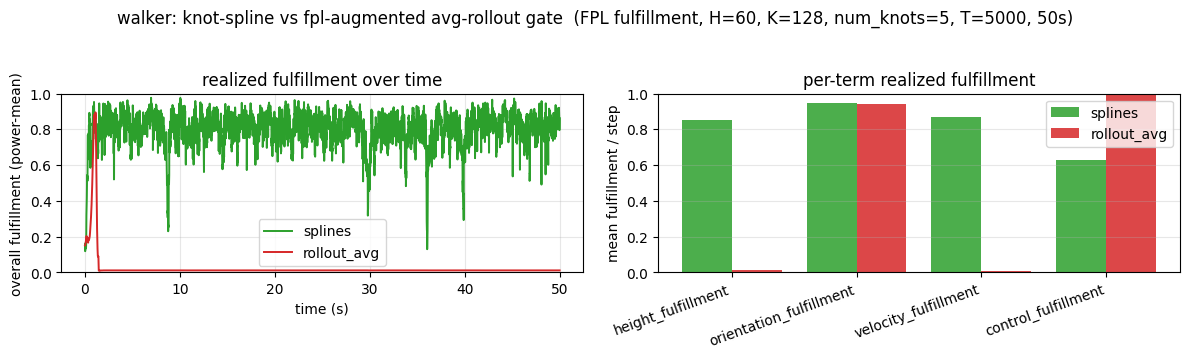


[hopper] H=30 nu=3 T=2500 (50s)  num_knots=15 (cubic) latent_D=12 K=120  avg_window=100 avg_states=10  (FPL fulfillment; PCA augmented with scalar fpl reward)
      method | plan time | mean fulfil | overall F
     splines |    38.91s |      0.7716 |    0.6714
    [fpl-avg-select @ 200] over 10 states: cos=-9.8021e-01 pca=-9.8261e-01 -> pca(d=12)
    [fpl-avg-select @ 400] over 10 states: cos=-9.8414e-01 pca=-9.8559e-01 -> pca(d=12)
    [fpl-avg-select @ 600] over 10 states: cos=-9.8523e-01 pca=-9.8740e-01 -> pca(d=12)
    [fpl-avg-select @ 800] over 10 states: cos=-7.7882e-01 pca=-7.7551e-01 -> cosine(d=12)
    [fpl-avg-select @ 1000] over 10 states: cos=-9.2465e-02 pca=-9.2528e-02 -> pca(d=12)
    [fpl-avg-select @ 1200] over 10 states: cos=-8.3101e-02 pca=-7.8244e-02 -> cosine(d=12)
    [fpl-avg-select @ 1400] over 10 states: cos=-9.0914e-02 pca=-9.0649e-02 -> cosine(d=12)
    [fpl-avg-select @ 1600] over 10 states: cos=-9.1800e-02 pca=-9.1986e-02 -> pca(d=12)
    [fpl-avg-select @

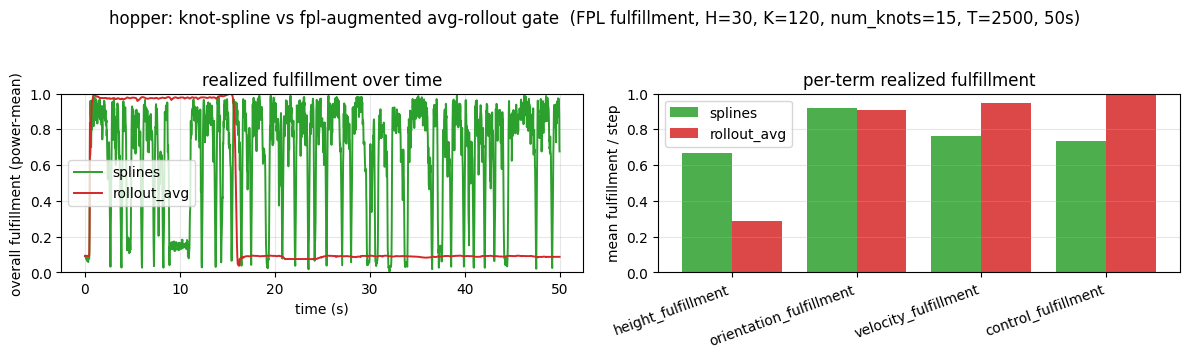


[g1_standup] H=30 nu=29 T=2500 (50s)  num_knots=4 (zero) latent_D=87 K=128  avg_window=100 avg_states=10  (FPL fulfillment; PCA augmented with scalar fpl reward)
      method | plan time | mean fulfil | overall F
     splines |   294.16s |      0.8632 |    0.8515
    [fpl-avg-select @ 200] over 10 states: cos=-2.5055e-01 pca=-2.3081e-01 -> cosine(d=87)
    [fpl-avg-select @ 400] over 10 states: cos=-2.5721e-01 pca=-2.3754e-01 -> cosine(d=87)
    [fpl-avg-select @ 600] over 10 states: cos=-2.6869e-01 pca=-2.6670e-01 -> cosine(d=87)
    [fpl-avg-select @ 800] over 10 states: cos=-2.4939e-01 pca=-2.5558e-01 -> pca(d=87)


KeyboardInterrupt: 

In [56]:
# ============================================================================
# Run: knot-spline (FPL) vs fpl-augmented avg-rollout gate on walker/hopper/g1.
# Re-run THIS cell alone to re-test a run; all defs live in the cell above.
# ============================================================================
for env_name, cfg in LAT_CFG.items():
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    T = round(SIM_TIME / backend.dt)
    H = round(cfg["plan_horizon"] / backend.dt)
    state0 = backend.get_state().copy()
    t_axis = backend.dt * np.arange(T + 1)
    cost_fn = make_cost_fn_fpl(task)

    ctrls = {"splines":     build_knots_fpl(task, backend, cfg),
             "rollout_avg": build_avg_gate_fpl(task, H, cfg)}

    runs = {}
    print(f"\n[{env_name}] H={H} nu={task.nu} T={T} ({SIM_TIME:g}s)  "
          f"num_knots={cfg['num_knots']} ({cfg['spline_type']}) latent_D={cfg['k'] * task.nu} "
          f"K={cfg['K']}  avg_window={AVG_WINDOW} avg_states={AVG_STATES}  "
          f"(FPL fulfillment; PCA augmented with scalar fpl reward)")
    print(f"{'method':>12s} | {'plan time':>9s} | {'mean fulfil':>11s} | {'overall F':>9s}")
    for m in FPL_METHODS:
        ctrl = ctrls[m]
        sh, ch, tp = run_cl_any(ctrl, backend, state0, T, cost_fn)
        ful = realized_terms_f(sh, ch, task, backend)              # (T, n_terms_f) in [0,1]
        runs[m] = dict(stage=power_mean(ful, FPL_P), per_term=ful.mean(axis=0))
        extra = ""
        if isinstance(ctrl, LatentMPPI):
            sl = ctrl.switch_log
            npca = sum(1 for s in sl if s[1] == "pca")
            extra = f"  final={ctrl.basis_name} pca_chosen={npca}/{len(sl)}"
        print(f"{m:>12s} | {tp:8.2f}s | {ful.mean():11.4f} | {runs[m]['stage'].mean():9.4f}{extra}")

    labels = list(task.cost_term_names_f)
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.4))
    for m in FPL_METHODS:
        axL.plot(t_axis[1:], runs[m]["stage"], color=FPL_COLORS[m], lw=1.4, label=m)
    axL.set_xlabel("time (s)"); axL.set_ylabel("overall fulfillment (power-mean)")
    axL.set_ylim(0, 1); axL.set_title("realized fulfillment over time")
    axL.legend(loc="best"); axL.grid(alpha=0.3)

    x = np.arange(len(labels)); w = 0.8 / len(FPL_METHODS)
    for i, m in enumerate(FPL_METHODS):
        axR.bar(x + (i - (len(FPL_METHODS) - 1) / 2) * w, runs[m]["per_term"], w,
                color=FPL_COLORS[m], alpha=0.85, label=m)
    axR.set_ylim(0, 1); axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
    axR.set_ylabel("mean fulfillment / step"); axR.set_title("per-term realized fulfillment")
    axR.legend(loc="best"); axR.grid(axis="y", alpha=0.3)

    fig.suptitle(f"{env_name}: knot-spline vs fpl-augmented avg-rollout gate  "
                 f"(FPL fulfillment, H={H}, K={cfg['K']}, num_knots={cfg['num_knots']}, "
                 f"T={T}, {SIM_TIME:g}s)", y=1.04)
    fig.tight_layout(); plt.show()

## Self-contained: HTML render (walker + hopper) + avg-rollout-gate vs splines

A **standalone** cell (it depends on no other cell — it re-imports and re-defines
everything it needs). It (1) renders **HTML videos** (each **≥ 10 s**, ~real time) of
the walker and hopper executing **both** controllers' trajectories — knot-spline MPPI
(`MPPIv2`) and the averaged rollout-cost gate (`LatentMPPIAvgGate`) — and (2) charts
**average cost over time** (per-step) and **average cost per term** for the two methods.

The two latent dimensions are exposed at the top and are independently configurable:
`COSINE_K` (cosine DCT modes **per actuator** → cosine latent dim `COSINE_K·nu`) and
`PCA_D` (absolute number of PCA components). The gate picks cosine(`COSINE_K·nu`) vs
PCA(`PCA_D`) at each refit by the lower min-cost averaged over recent states.

config: COSINE_K=4 (cos dim/env = 4*nu) | PCA_D=12 | K=48 SIM_TIME=10.0s plan_horizon=0.5s

[walker] nu=6 H=50 T=1000 (10s)  cos_dim=24 pca_d=12
      method | plan time |  realized J | avg J/step
     splines |     8.82s |     324.227 |     0.3242
 rollout_avg |    11.30s |    1291.146 |     1.2911  final=pca pca_chosen=10/10


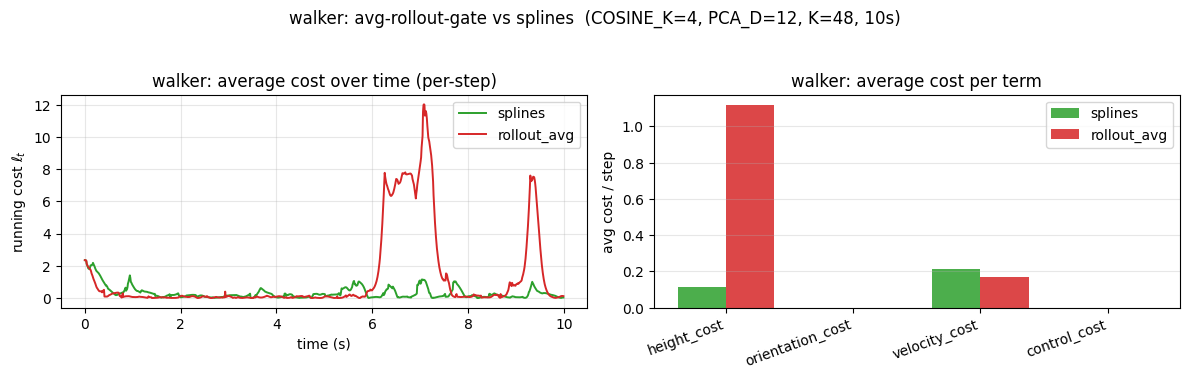


[hopper] nu=3 H=25 T=500 (10s)  cos_dim=12 pca_d=12
      method | plan time |  realized J | avg J/step
     splines |     2.15s |    4078.712 |     8.1574
 rollout_avg |     2.67s |     690.728 |     1.3815  final=pca pca_chosen=2/5


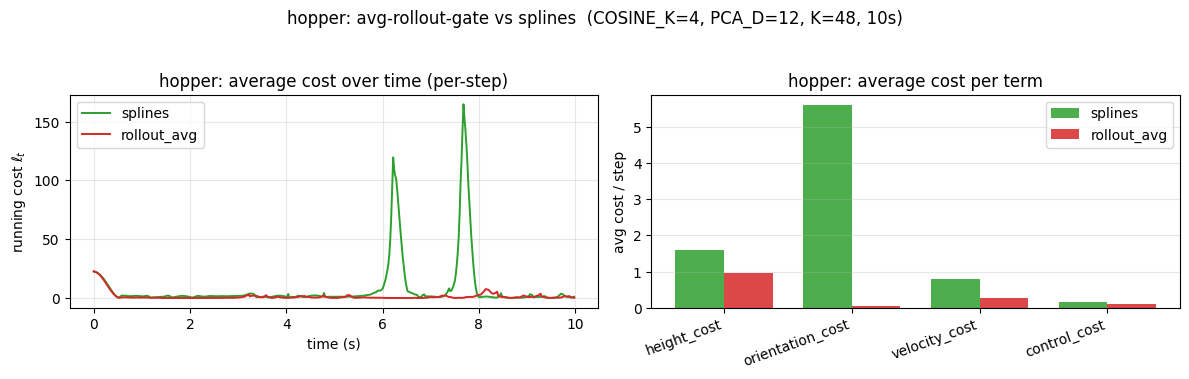

In [48]:
# ============================================================================
# SELF-CONTAINED: HTML render (walker + hopper) + avg-rollout-gate vs splines
# ============================================================================
# Standalone cell -- it redefines EVERYTHING it needs and does NOT depend on any
# other cell. Configure the two latent dimensions at the top:
#   COSINE_K -> cosine (DCT) modes PER ACTUATOR  (cosine latent dim = COSINE_K*nu)
#   PCA_D    -> PCA components (absolute latent dim)
# The averaged rollout-cost gate picks cosine(COSINE_K*nu) vs PCA(PCA_D) each
# refit by the lower min-cost averaged over the last AVG_STATES visited states.
import time, io, base64, tempfile, os
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import mujoco
import imageio
from IPython.display import HTML, display

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPIv2

# ------------------------- configurable knobs -------------------------
COSINE_K = 4          # <-- cosine modes per actuator  (cosine latent dim = COSINE_K * nu)
PCA_D    = 12         # <-- PCA components             (PCA latent dim, absolute)

ENVS         = ("walker", "hopper")
SIM_TIME     = 10.0   # closed-loop seconds -> also the (real-time) length of each render
PLAN_HORIZON = 0.5    # planning horizon in seconds
N_SAMPLES    = 48
SEED         = 0
SIGMA_COS, SIGMA_PCA, LAM = 0.5, 1.0, 1.0
NUM_KNOTS, KNOT_SPLINE = 5, "cubic"                     # splines (MPPIv2) parameterization
ADAPT = dict(buffer_size=300, refit_every=100, warmup=80, explore_frac=0.2)
AVG_WINDOW, AVG_STATES = 60, 6                          # gate: window of states, #subsampled per refit
# width/height divisible by 16 (no re-encode resize); fps is derived so each clip lasts >= min_seconds.
RENDER = dict(width=320, height=240, stride=3, min_seconds=10.0)


# ------------------------- latent bases (cosine / PCA) -------------------------
class CosineBasis:
    """Fixed orthonormal DCT-II basis, k modes per actuator (dim k*nu)."""
    def __init__(self, H, nu, k):
        d = int(min(k, H))
        n = np.arange(H)[:, None]; j = np.arange(d)[None, :]
        Phi = np.cos(np.pi * (2 * n + 1) * j / (2 * H))
        a = np.full(d, np.sqrt(2.0 / H)); a[0] = np.sqrt(1.0 / H)
        self.Phi = Phi * a
        self.H, self.nu, self.k = H, nu, d
    @property
    def latent_shape(self): return (self.k, self.nu)
    def encode(self, U): return np.einsum("hk,...hj->...kj", self.Phi, U)
    def decode(self, z): return np.einsum("hk,...kj->...hj", self.Phi, z)


class PCABasis:
    """Whitened PCA basis fit over flattened (H*nu) plans, kept at rank D."""
    def __init__(self, B, H, nu, D, eps=1e-8):
        self.mean = B.mean(axis=0)
        Bc = B - self.mean
        _, S, Vt = np.linalg.svd(Bc, full_matrices=False)
        d = int(min(D, Vt.shape[0]))
        self.V = Vt[:d]
        N = max(Bc.shape[0] - 1, 1)
        self.s = (S[:d] / np.sqrt(N)) + eps
        self.H, self.nu, self.d = H, nu, d
    @property
    def latent_shape(self): return (self.d,)
    def encode(self, U):
        flat = U.reshape(U.shape[:-2] + (self.H * self.nu,))
        return ((flat - self.mean) @ self.V.T) / self.s
    def decode(self, z):
        flat = self.mean + (z * self.s) @ self.V
        return flat.reshape(z.shape[:-1] + (self.H, self.nu))


class LatentMPPI:
    """MPPI sampling in a latent basis; rollout-cost gate selects cosine vs PCA.

    Decoupled dimensions: the cosine basis has `cosine_k` modes/actuator (dim
    cosine_k*nu) and the PCA basis is fit at `pca_d` components -- they need not
    match. Selection is reversible (no margin / no freeze)."""
    def __init__(self, *, horizon, n_samples, nu, lambda_, u_min=None, u_max=None,
                 seed=0, cosine_k=4, pca_d=12, sigma_cos=0.5, sigma_pca=1.0,
                 gate_mode="rollout", buffer_size=600, refit_every=200, warmup=200,
                 explore_frac=0.2, verbose=False):
        self.H, self.K, self.nu = horizon, n_samples, nu
        self.lambda_ = lambda_
        self.u_min = None if u_min is None else np.asarray(u_min, float).reshape(nu)
        self.u_max = None if u_max is None else np.asarray(u_max, float).reshape(nu)
        self.seed = seed
        self.cosine_k, self.pca_d = int(cosine_k), int(pca_d)
        self.sigma_cos, self.sigma_pca = sigma_cos, sigma_pca
        self.gate_mode = gate_mode
        self.buffer_size = buffer_size
        self.refit_every, self.warmup = refit_every, warmup
        self.explore_frac = explore_frac if gate_mode is not None else 0.0
        self.verbose = verbose
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(self.seed)
        self.cosine = CosineBasis(self.H, self.nu, self.cosine_k)
        self.active = self.cosine
        self.basis_name = "cosine"
        self.mu_z = np.zeros(self.active.latent_shape)
        self.buffer = deque(maxlen=self.buffer_size)
        self.step = 0
        self.switch_log = []

    def _clip(self, U):
        if self.u_min is not None or self.u_max is not None:
            return np.clip(U, self.u_min, self.u_max)
        return U

    def _sample(self, basis, center_z, sigma, K):
        z = center_z[None] + sigma * self.rng.normal(size=(K,) + center_z.shape)
        return basis.decode(z)

    def _sigma_for(self, basis):
        return self.sigma_cos if basis is self.cosine else self.sigma_pca

    def _rollout_cost(self, U, state, cost_fn, backend):
        U = self._clip(U)
        initial = np.broadcast_to(state, (U.shape[0], state.shape[0])).copy()
        states, sensordata = backend.rollout(initial, U)
        return np.asarray(cost_fn(states, U, sensordata), float).reshape(U.shape[0])

    def act(self, state, cost_fn, backend):
        K_res = int(round(self.K * self.explore_frac)); K_main = self.K - K_res
        U_main = self._sample(self.active, self.mu_z, self._sigma_for(self.active), K_main)
        if K_res > 0:
            c0 = self.cosine.encode(self.active.decode(self.mu_z))
            U = np.concatenate([U_main, self._sample(self.cosine, c0, self.sigma_cos, K_res)], axis=0)
        else:
            U = U_main
        U = self._clip(U)
        costs = self._rollout_cost(U, state, cost_fn, backend)
        beta = costs.min(); w = np.exp(-(costs - beta) / self.lambda_); s = w.sum()
        U_new = U[int(np.argmin(costs))].copy() if (s <= 0 or not np.isfinite(s)) \
            else (w[:, None, None] / s * U).sum(axis=0)
        self.mu_z = self.active.encode(U_new)
        self.buffer.append(U_new.reshape(-1).copy())
        self.step += 1
        if self.gate_mode is not None:
            self._maybe_select(state, cost_fn, backend)
        U_nom = self.active.decode(self.mu_z)
        u0 = self._clip(U_nom[0].copy())
        U_shift = np.roll(U_nom, -1, axis=0); U_shift[-1] = 0.0
        self.mu_z = self.active.encode(U_shift)
        return u0

    def _maybe_select(self, state, cost_fn, backend):
        if self.step % self.refit_every != 0 or len(self.buffer) < self.warmup:
            return
        B = np.asarray(self.buffer); n_recent = max(1, B.shape[0] // 4)
        older = B[:-n_recent]
        if older.shape[0] <= self.pca_d:
            return
        cand = PCABasis(older, self.H, self.nu, self.pca_d)
        nominal_U = self.active.decode(self.mu_z)
        U_cos = self._sample(self.cosine, self.cosine.encode(nominal_U), self.sigma_cos, self.K)
        U_pca = self._sample(cand, cand.encode(nominal_U), self.sigma_pca, self.K)
        m_cos = float(self._rollout_cost(U_cos, state, cost_fn, backend).min())
        m_pca = float(self._rollout_cost(U_pca, state, cost_fn, backend).min())
        self._switch_to(cand, m_cos, m_pca)

    def _switch_to(self, cand, m_cos, m_pca):
        choose = "pca" if m_pca < m_cos else "cosine"
        target = cand if choose == "pca" else self.cosine
        if target is not self.active:
            self.mu_z = target.encode(self.active.decode(self.mu_z)); self.active = target
        self.basis_name = choose
        self.switch_log.append((self.step, choose, m_cos, m_pca))


class LatentMPPIAvgGate(LatentMPPI):
    """Rollout-cost gate whose cosine-vs-PCA metric is the AVERAGE min sample-cost
    over the last AVG_STATES visited states (subsampled from a window of AVG_WINDOW)."""
    def __init__(self, *args, avg_window=AVG_WINDOW, avg_states=AVG_STATES, **kw):
        self.avg_window, self.avg_states = int(avg_window), int(avg_states)
        super().__init__(*args, gate_mode="rollout", **kw)

    def reset(self):
        super().reset(); self.state_hist = deque(maxlen=self.avg_window)

    def act(self, state, cost_fn, backend):
        self.state_hist.append(np.asarray(state, float).copy())
        return super().act(state, cost_fn, backend)

    def _maybe_select(self, state, cost_fn, backend):
        if self.step % self.refit_every != 0 or len(self.buffer) < self.warmup:
            return
        B = np.asarray(self.buffer); n_recent = max(1, B.shape[0] // 4)
        older = B[:-n_recent]
        if older.shape[0] <= self.pca_d:
            return
        cand = PCABasis(older, self.H, self.nu, self.pca_d)
        hist = list(self.state_hist)
        if len(hist) > self.avg_states:
            idx = np.linspace(0, len(hist) - 1, self.avg_states).round().astype(int)
            hist = [hist[i] for i in idx]
        nominal_U = self.active.decode(self.mu_z)
        c_cos = c_pca = 0.0
        for s in hist:
            U_cos = self._sample(self.cosine, self.cosine.encode(nominal_U), self.sigma_cos, self.K)
            U_pca = self._sample(cand, cand.encode(nominal_U), self.sigma_pca, self.K)
            c_cos += float(self._rollout_cost(U_cos, s, cost_fn, backend).min())
            c_pca += float(self._rollout_cost(U_pca, s, cost_fn, backend).min())
        self._switch_to(cand, c_cos / len(hist), c_pca / len(hist))


# ------------------------- cost helpers (same convention as the other cells) -------------------------
def make_cost_fn(task):
    def cost_fn(states, controls, sensordata):
        qpos, qvel = task.qpos_of(states), task.qvel_of(states)
        running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2))
        terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
        return running + terminal
    return cost_fn


def realized_terms(states_hist, ctrl_hist, task, backend):
    post, sens = backend.rollout(states_hist[:-1], ctrl_hist[:, None, :])
    qpos, qvel = task.qpos_of(post[:, 0]), task.qvel_of(post[:, 0])
    return task.running_cost_terms(qpos, qvel, sens[:, 0], ctrl_hist)


# ------------------------- controllers + closed-loop driver -------------------------
def build_splines(task, backend, H):
    return MPPIv2(task=task, backend=backend, num_samples=N_SAMPLES, noise_level=SIGMA_COS,
                  temperature=LAM, num_knots=NUM_KNOTS, plan_horizon=PLAN_HORIZON,
                  spline_type=KNOT_SPLINE, seed=SEED)


def build_avg_gate(task, H):
    return LatentMPPIAvgGate(horizon=H, n_samples=N_SAMPLES, nu=task.nu, lambda_=LAM,
                             u_min=task.u_min, u_max=task.u_max, seed=SEED,
                             cosine_k=COSINE_K, pca_d=PCA_D, sigma_cos=SIGMA_COS, sigma_pca=SIGMA_PCA,
                             avg_window=AVG_WINDOW, avg_states=AVG_STATES, **ADAPT)


def run_cl_any(ctrl, backend, state0, T, cost_fn):
    backend.set_state(state0); ctrl.reset()
    knot_api = isinstance(ctrl, MPPIv2)
    states_hist, ctrl_hist, t_plan = [backend.get_state().copy()], [], 0.0
    for _ in range(T):
        state = backend.get_state()
        t0 = time.perf_counter()
        u0 = ctrl.act(state) if knot_api else ctrl.act(state, cost_fn, backend)
        t_plan += time.perf_counter() - t0
        backend.step(u0)
        states_hist.append(backend.get_state().copy()); ctrl_hist.append(u0.copy())
    return np.array(states_hist), np.array(ctrl_hist), t_plan


# ------------------------- MuJoCo -> HTML video -------------------------
def render_html(backend, states, title, *, width, height, stride, min_seconds):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(backend.model, cam)
    cam.distance, cam.elevation = 4.0, -15.0
    r = mujoco.Renderer(backend.model, height=height, width=width)
    frames = []
    for s in states[::stride]:
        backend.set_state(s)
        cam.lookat[0] = float(backend.data.qpos[0])     # track forward (+x) motion
        r.update_scene(backend.data, cam)
        frames.append(r.render())
    r.close()
    # pick fps so the clip lasts >= min_seconds (capped at 60 for smoothness); with the
    # defaults this is ~real time, so each render shows the full SIM_TIME of behaviour.
    fps = min(60.0, max(1.0, len(frames) / float(min_seconds)))
    dur = len(frames) / fps
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as f:
        path = f.name
    imageio.mimwrite(path, np.asarray(frames), fps=fps, codec="libx264")  # imageio defaults to yuv420p
    data = open(path, "rb").read(); os.remove(path)
    b64 = base64.b64encode(data).decode()
    return (f'<figure style="display:inline-block;margin:8px;text-align:center">'
            f'<figcaption><b>{title}</b> &middot; {dur:.0f}s</figcaption>'
            f'<video controls autoplay loop muted width="{width}">'
            f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video></figure>')


# ------------------------- run, render, chart -------------------------
METHODS = ("splines", "rollout_avg")
COLORS  = {"splines": "tab:green", "rollout_avg": "tab:red"}
print(f"config: COSINE_K={COSINE_K} (cos dim/env = {COSINE_K}*nu) | PCA_D={PCA_D} | "
      f"K={N_SAMPLES} SIM_TIME={SIM_TIME}s plan_horizon={PLAN_HORIZON}s")
video_html = []

for env_name in ENVS:
    task = make_task(env_name); backend = MujocoBackend(task.model_path)
    T = round(SIM_TIME / backend.dt); H = round(PLAN_HORIZON / backend.dt)
    state0 = backend.get_state().copy(); cost_fn = make_cost_fn(task)
    t_axis = backend.dt * np.arange(T)

    runs, exec_states = {}, {}
    print(f"\n[{env_name}] nu={task.nu} H={H} T={T} ({SIM_TIME:g}s)  "
          f"cos_dim={COSINE_K * task.nu} pca_d={PCA_D}")
    print(f"{'method':>12s} | {'plan time':>9s} | {'realized J':>11s} | {'avg J/step':>10s}")
    for m in METHODS:
        ctrl = build_splines(task, backend, H) if m == "splines" else build_avg_gate(task, H)
        sh, ch, tp = run_cl_any(ctrl, backend, state0, T, cost_fn)
        terms = realized_terms(sh, ch, task, backend)        # (T, n_terms)
        runs[m] = terms; exec_states[m] = sh
        extra = ""
        if isinstance(ctrl, LatentMPPIAvgGate):
            npca = sum(1 for s in ctrl.switch_log if s[1] == "pca")
            extra = f"  final={ctrl.basis_name} pca_chosen={npca}/{len(ctrl.switch_log)}"
        print(f"{m:>12s} | {tp:8.2f}s | {terms.sum():11.3f} | {terms.sum()/terms.shape[0]:10.4f}{extra}")

    # ---- HTML render of this environment's executed trajectory for BOTH methods ----
    for m in METHODS:
        video_html.append(render_html(backend, exec_states[m], f"{env_name} ({m})", **RENDER))

    # ---- chart: average cost over time (left) + average cost per term (right) ----
    labels = list(task.cost_term_names)
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.6))
    for m in METHODS:
        axL.plot(t_axis, runs[m].sum(axis=1), color=COLORS[m], lw=1.4, label=m)
    axL.set_xlabel("time (s)"); axL.set_ylabel(r"running cost $\ell_t$")
    axL.set_title(f"{env_name}: average cost over time (per-step)"); axL.legend(); axL.grid(alpha=0.3)

    x = np.arange(len(labels)); w = 0.38
    for i, m in enumerate(METHODS):
        axR.bar(x + (i - 0.5) * w, runs[m].mean(axis=0), w, color=COLORS[m], alpha=0.85, label=m)
    axR.set_xticks(x); axR.set_xticklabels(labels, rotation=20, ha="right")
    axR.set_ylabel("avg cost / step"); axR.set_title(f"{env_name}: average cost per term")
    axR.legend(); axR.grid(axis="y", alpha=0.3)
    fig.suptitle(f"{env_name}: avg-rollout-gate vs splines  "
                 f"(COSINE_K={COSINE_K}, PCA_D={PCA_D}, K={N_SAMPLES}, {SIM_TIME:g}s)", y=1.04)
    fig.tight_layout(); plt.show()

display(HTML("<div>" + "".join(video_html) + "</div>"))
